In [56]:
import pandas as pd
import plotly.express as px
import chart_studio.plotly as py
import cufflinks as cf
cf.go_offline(connected=True)
import matplotlib.pyplot as plt
import numpy as np
import string

from factor_analyzer import calculate_kmo
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats

In [57]:
df = pd.read_csv('world-data-2023.csv')
df

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,32,VE,24.50%,"912,050","343,000",17.88,58.0,Caracas,"164,175",...,45.80%,1.92,"28,515,829",59.70%,NaN,73.30%,8.80%,"25,162,368",6.423750,-66.589730
191,Vietnam,314,VN,39.30%,"331,210","522,000",16.75,84.0,Hanoi,"192,668",...,43.50%,0.82,"96,462,106",77.40%,19.10%,37.60%,2.01%,"35,332,140",14.058324,108.277199
192,Yemen,56,YE,44.60%,"527,968","40,000",30.45,967.0,Sanaa,"10,609",...,81.00%,0.31,"29,161,922",38.00%,NaN,26.60%,12.91%,"10,869,523",15.552727,48.516388
193,Zambia,25,ZM,32.10%,"752,618","16,000",36.19,260.0,Lusaka,"5,141",...,27.50%,1.19,"17,861,030",74.60%,16.20%,15.60%,11.43%,"7,871,713",-13.133897,27.849332


In [58]:
drop_features = ['Abbreviation', 'Capital/Major City', 'Latitude', 'Longitude',
                 'Official language','Density\n(P/Km2)','Calling Code','Currency-Code',
                 'CPI Change (%)','Birth Rate','Co2-Emissions','CPI Change (%)',
                 'Fertility Rate','Gross primary education enrollment (%)',
                 'Gross tertiary education enrollment (%)','Minimum wage',
                 'Out of pocket health expenditure','Physicians per thousand',
                 'Tax revenue (%)','Total tax rate','Maternal mortality ratio',
                 'Gasoline Price','Largest city','CPI']
df.drop(drop_features, axis=1, inplace=True)
df

,Country,Agricultural Land( %),Land Area(Km2),Armed Forces size,Forested Area (%),GDP,Infant mortality,Life expectancy,Population,Population: Labor force participation (%),Unemployment rate,Urban_population
0,Afghanistan,58.10%,"652,230","323,000",2.10%,"$19,101,353,833",47.9,64.5,"38,041,754",48.90%,11.12%,"9,797,273"
1,Albania,43.10%,"28,748","9,000",28.10%,"$15,278,077,447",7.8,78.5,"2,854,191",55.70%,12.33%,"1,747,593"
2,Algeria,17.40%,"2,381,741","317,000",0.80%,"$169,988,236,398",20.1,76.7,"43,053,054",41.20%,11.70%,"31,510,100"
3,Andorra,40.00%,468,NaN,34.00%,"$3,154,057,987",2.7,NaN,"77,142",NaN,NaN,"67,873"
4,Angola,47.50%,"1,246,700","117,000",46.30%,"$94,635,415,870",51.6,60.8,"31,825,295",77.50%,6.89%,"21,061,025"
...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,24.50%,"912,050","343,000",52.70%,"$482,359,318,768",21.4,72.1,"28,515,829",59.70%,8.80%,"25,162,368"
191,Vietnam,39.30%,"331,210","522,000",48.10%,"$261,921,244,843",16.5,75.3,"96,462,106",77.40%,2.01%,"35,332,140"
192,Yemen,44.60%,"527,968","40,000",1.00%,"$26,914,402,224",42.9,66.1,"29,161,922",38.00%,12.91%,"10,869,523"
193,Zambia,32.10%,"752,618","16,000",65.20%,"$23,064,722,446",40.4,63.5,"17,861,030",74.60%,11.43%,"7,871,713"


In [59]:
df = df.dropna()
df['Agricultural Land( %)'] = df['Agricultural Land( %)'].str.replace('%', '').astype(float)
df['Land Area(Km2)'] = df['Land Area(Km2)'].str.replace(',', '').astype(int)
df['Armed Forces size'] = df['Armed Forces size'].str.replace(',','').astype(int)
df['Forested Area (%)'] = df['Forested Area (%)'].str.replace('%','').astype(float)
df['Population'] = df['Population'].str.replace(',','').astype(int)
df['Population: Labor force participation (%)'] = df['Population: Labor force participation (%)'].str.replace('%','').astype(float)
df['Unemployment rate'] = df['Unemployment rate'].str.replace('%','').astype(float)
df['Urban_population'] = df['Urban_population'].str.replace(',','').astype(int)
df['GDP'] = df['GDP'].str.replace('$', '')
df['GDP'] = df['GDP'].str.replace(',', '').astype('longlong')
df

,Country,Agricultural Land( %),Land Area(Km2),Armed Forces size,Forested Area (%),GDP,Infant mortality,Life expectancy,Population,Population: Labor force participation (%),Unemployment rate,Urban_population
0,Afghanistan,58.1,652230,323000,2.1,19101353833,47.9,64.5,38041754,48.9,11.12,9797273
1,Albania,43.1,28748,9000,28.1,15278077447,7.8,78.5,2854191,55.7,12.33,1747593
2,Algeria,17.4,2381741,317000,0.8,169988236398,20.1,76.7,43053054,41.2,11.70,31510100
4,Angola,47.5,1246700,117000,46.3,94635415870,51.6,60.8,31825295,77.5,6.89,21061025
6,Argentina,54.3,2780400,105000,9.8,449663446954,8.8,76.5,44938712,61.3,9.79,41339571
...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,24.5,912050,343000,52.7,482359318768,21.4,72.1,28515829,59.7,8.80,25162368
191,Vietnam,39.3,331210,522000,48.1,261921244843,16.5,75.3,96462106,77.4,2.01,35332140
192,Yemen,44.6,527968,40000,1.0,26914402224,42.9,66.1,29161922,38.0,12.91,10869523
193,Zambia,32.1,752618,16000,65.2,23064722446,40.4,63.5,17861030,74.6,11.43,7871713


In [60]:
mean_values = df.mean(numeric_only=True)
std_values = df.std(numeric_only=True)

print('변수 평균: \n',mean_values)
print('변수 표준편차: \n', std_values)

변수 평균: 
 Agricultural Land( %)                        4.024583e+01
Land Area(Km2)                               7.919445e+05
Armed Forces size                            1.610179e+05
Forested Area (%)                            3.020476e+01
GDP                                          5.479655e+11
Infant mortality                             2.147976e+01
Life expectancy                              7.232381e+01
Population                                   4.537260e+07
Population: Labor force participation (%)    6.271429e+01
Unemployment rate                            6.793929e+00
Urban_population                             2.520555e+07
dtype: float64
변수 표준편차: 
 Agricultural Land( %)                        2.183590e+01
Land Area(Km2)                               2.046098e+06
Armed Forces size                            3.836275e+05
Forested Area (%)                            2.276250e+01
GDP                                          2.320751e+12
Infant mortality                     

In [61]:
df.corr(numeric_only=True).iplot(kind = 'heatmap', colorscale ='Blues')

In [62]:
numeric_df = df.select_dtypes(include='number')
kmo_all, kmo_model = calculate_kmo(numeric_df)

print('MSA: \n',kmo_all)

MSA: 
 [0.49565282 0.75537789 0.84051595 0.47203346 0.6685009  0.4946571
 0.48393716 0.61287972 0.47299834 0.42150642 0.6430877 ]


In [63]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

pca = PCA()
pca.fit(scaled_data)

eigenvalues = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_

print('고유값:\n',eigenvalues)
print('\n설명력:\n',explained_variance_ratio)

고유값:
 [3.81472186 2.08184185 1.66273379 1.16625154 0.70017093 0.58002297
 0.4796879  0.37197157 0.13209714 0.05853849 0.01783023]

설명력:
 [0.34472865 0.18813181 0.15025787 0.10539178 0.06327302 0.0524155
 0.04334842 0.03361431 0.01193735 0.00529    0.00161128]


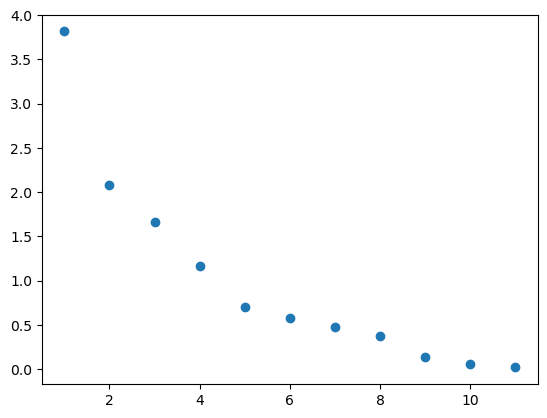

In [64]:
plt.scatter(range(1,12),eigenvalues , label='Data points')

In [65]:
df['Country']

0      Afghanistan
1          Albania
2          Algeria
4           Angola
6        Argentina
          ...     
190      Venezuela
191        Vietnam
192          Yemen
193         Zambia
194       Zimbabwe
Name: Country, Length: 168, dtype: object

In [66]:
from factor_analyzer import FactorAnalyzer

In [67]:
fa = FactorAnalyzer(n_factors=5, rotation=None)
fa.fit(df.drop(columns='Country'))
initial_loadings = fa.loadings_
print('회전 전 인자적재행렬:')
print(initial_loadings)

회전 전 인자적재행렬:
[[ 0.0601105   0.4626853  -0.69316606  0.54398481  0.05262507]
 [ 0.58464964  0.00254541  0.07310991 -0.088973    0.26922095]
 [ 0.8757869   0.06871242  0.04479203 -0.04486554 -0.12225169]
 [-0.01840097 -0.14775306  0.3901495  -0.15386622  0.01772147]
 [ 0.78371983 -0.04278859  0.02479138  0.02074593  0.34428998]
 [-0.17129195  0.88136315  0.16081901 -0.17790419 -0.00260958]
 [ 0.1834664  -0.95302506 -0.15418709  0.18827586 -0.04405687]
 [ 0.93512811  0.18198983  0.02955446  0.01332483 -0.30681144]
 [-0.08507794  0.1394349   0.60487301  0.49012224  0.12382276]
 [ 0.00942768  0.01265966 -0.45904232 -0.44794518  0.14105286]
 [ 0.97853318  0.11110075  0.03212077  0.00814136 -0.01967115]]


In [68]:
fa.rotation = 'varimax'
fa.fit(df.drop(columns='Country'))
rotated_loadings = fa.loadings_
print('회전 된 인자적재행렬:')
print(rotated_loadings)

회전 된 인자적재행렬:
[[ 3.82253667e-02  1.35739371e-01  9.87811167e-01 -1.81696248e-03
   3.46186962e-02]
 [ 5.82253804e-01 -2.88062625e-02 -7.77287620e-02 -4.64092682e-02
   2.81989325e-01]
 [ 8.81993339e-01 -3.67253012e-02 -2.65213492e-03 -2.40112039e-02
  -1.04135667e-01]
 [ 2.17935104e-04 -1.36597787e-02 -4.26776340e-01  1.23560428e-01
   2.79857486e-02]
 [ 7.64579651e-01 -1.35089854e-01  1.62271472e-02 -6.39961943e-03
   3.63995397e-01]
 [-4.78593154e-02  9.24031039e-01  6.75503059e-02  4.35350295e-02
  -3.28508672e-02]
 [ 5.26374605e-02 -9.95325289e-01 -9.06431729e-02 -3.60561732e-02
  -1.09446092e-02]
 [ 9.54225822e-01  3.58388430e-02  8.07441973e-02  2.26147220e-02
  -2.89666642e-01]
 [-4.18779419e-02  1.33751805e-01 -1.08150926e-01  7.72272796e-01
   1.42682832e-01]
 [-1.08828793e-02  4.43792208e-02  7.83948425e-02 -6.39437372e-01
   1.20024737e-01]
 [ 9.83547266e-01 -2.48679405e-02  5.78402136e-02  5.13629451e-03
   1.90419135e-04]]


In [69]:
varimax_matrix = fa.rotation_matrix_
print('\n 회전행렬:')
print(varimax_matrix)


 회전행렬:
[[ 0.98928963  0.13477395 -0.04023522 -0.03173901 -0.02271044]
 [-0.11624751  0.93042376  0.33724103 -0.07849796 -0.0300783 ]
 [ 0.07744702 -0.2020343   0.73214646  0.64540716 -0.02439799]
 [-0.03729184  0.27259899 -0.59025228  0.75858601 -0.02118078]
 [ 0.02009513  0.03193033  0.01460879  0.02876766  0.99876706]]


In [70]:
loadings_df = pd.DataFrame(rotated_loadings, 
                            columns=[f'Factor_{i+1}' for i in range(rotated_loadings.shape[1])],
                            index=df.drop(columns='Country').columns)
print("\n인자적재점수:")
print(loadings_df)


인자적재점수:
                                           Factor_1  Factor_2  Factor_3  \
Agricultural Land( %)                      0.038225  0.135739  0.987811   
Land Area(Km2)                             0.582254 -0.028806 -0.077729   
Armed Forces size                          0.881993 -0.036725 -0.002652   
Forested Area (%)                          0.000218 -0.013660 -0.426776   
GDP                                        0.764580 -0.135090  0.016227   
Infant mortality                          -0.047859  0.924031  0.067550   
Life expectancy                            0.052637 -0.995325 -0.090643   
Population                                 0.954226  0.035839  0.080744   
Population: Labor force participation (%) -0.041878  0.133752 -0.108151   
Unemployment rate                         -0.010883  0.044379  0.078395   
Urban_population                           0.983547 -0.024868  0.057840   

                                           Factor_4  Factor_5  
Agricultural Land( %)     

In [71]:
factor_scores = fa.transform(df.drop(columns='Country'))
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_Score_{i+1}' for i in range(factor_scores.shape[1])])
result_df = pd.concat([df['Country'], factor_scores_df], axis=1)

print('각 국가에 대한 인자 점수:')
result_df = result_df.dropna()
print(result_df)

각 국가에 대한 인자 점수:
         Country  Factor_Score_1  Factor_Score_2  Factor_Score_3  \
0    Afghanistan       -0.133617        0.997249        0.718846   
1        Albania       -0.344022       -0.872630        0.306388   
2        Algeria        0.153386       -0.402921       -0.972882   
4         Angola        0.135629       -0.635764        0.729620   
6      Argentina        0.115132       -1.516803        0.714871   
..           ...             ...             ...             ...   
162  South Korea       -0.167047        0.002926        1.031729   
164        Spain        0.202443       -0.514819        0.058386   
165    Sri Lanka       -0.179826        0.939365        0.101104   
166        Sudan       -0.166420        1.120553       -0.519695   
167     Suriname       -0.193239        1.478709       -0.233283   

     Factor_Score_4  Factor_Score_5  
0         -1.181808       -0.018476  
1         -0.694660       -0.279763  
2         -1.801396        0.104883  
4         -0.24

In [72]:
fa = FactorAnalyzer(n_factors=5, rotation='quartimax')
fa.fit(df.drop(columns='Country'))
initial_loadings = fa.loadings_
print('인자적재행렬:')
print(initial_loadings)

인자적재행렬:
[[ 5.88926837e-02  1.41908826e-01  9.85664843e-01 -4.14318488e-02
   8.76989213e-04]
 [ 5.57056932e-01 -3.51421485e-02 -7.86937506e-02 -2.09458794e-02
   3.30732553e-01]
 [ 8.86732849e-01 -3.88662905e-02 -2.58175282e-02 -3.18464908e-02
  -3.46745961e-02]
 [-1.10125483e-02 -1.61383607e-02 -4.19848563e-01  1.43305760e-01
   3.44090635e-02]
 [ 7.34860539e-01 -1.42171820e-01  1.72138687e-02  2.18357703e-02
   4.17878307e-01]
 [-4.10125949e-02  9.25222721e-01  6.25304987e-02  3.33289191e-02
  -3.03545749e-02]
 [ 4.83953406e-02 -9.96110816e-01 -8.68289330e-02 -2.79568181e-02
  -1.33953740e-02]
 [ 9.75123518e-01  3.65151167e-02  4.91646563e-02 -3.72918610e-03
  -2.19405689e-01]
 [-4.92323979e-02  1.36274931e-01 -7.17911873e-02  7.84227844e-01
   8.33163942e-02]
 [-2.23941730e-02  3.95013979e-02  5.86239355e-02 -6.31106676e-01
   1.66509857e-01]
 [ 9.81784778e-01 -2.80387149e-02  3.81064095e-02  2.68094190e-03
   7.21716075e-02]]


In [73]:
quartimax_matrix = fa.rotation_matrix_
rotated_loadings = fa.loadings_
print('\n 회전행렬:')
print(quartimax_matrix)


 회전행렬:
[[ 0.98487018  0.13857422 -0.02070075 -0.03100411 -0.09715007]
 [-0.1289287   0.93304362  0.3297972  -0.05694951 -0.02824102]
 [ 0.06332161 -0.20047222  0.70754591  0.67459512 -0.01007381]
 [-0.02037098  0.26389521 -0.62201058  0.73374744  0.06827789]
 [ 0.09478141  0.01992487  0.05733157 -0.04828684  0.99247214]]


In [74]:
loadings_df = pd.DataFrame(rotated_loadings, 
                            columns=[f'Factor_{i+1}' for i in range(rotated_loadings.shape[1])],
                            index=df.drop(columns='Country').columns)
print("\n인자적재점수:")
print(loadings_df)


인자적재점수:
                                           Factor_1  Factor_2  Factor_3  \
Agricultural Land( %)                      0.058893  0.141909  0.985665   
Land Area(Km2)                             0.557057 -0.035142 -0.078694   
Armed Forces size                          0.886733 -0.038866 -0.025818   
Forested Area (%)                         -0.011013 -0.016138 -0.419849   
GDP                                        0.734861 -0.142172  0.017214   
Infant mortality                          -0.041013  0.925223  0.062530   
Life expectancy                            0.048395 -0.996111 -0.086829   
Population                                 0.975124  0.036515  0.049165   
Population: Labor force participation (%) -0.049232  0.136275 -0.071791   
Unemployment rate                         -0.022394  0.039501  0.058624   
Urban_population                           0.981785 -0.028039  0.038106   

                                           Factor_4  Factor_5  
Agricultural Land( %)     

In [75]:
factor_scores = fa.transform(df.drop(columns='Country'))
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_Score_{i+1}' for i in range(factor_scores.shape[1])])
result_df = pd.concat([df['Country'], factor_scores_df], axis=1)

print('각 국가에 대한 인자 점수:')
result_df = result_df.dropna()
print(result_df)

각 국가에 대한 인자 점수:
         Country  Factor_Score_1  Factor_Score_2  Factor_Score_3  \
0    Afghanistan       -0.120778        0.995347        0.666938   
1        Albania       -0.321883       -0.870163        0.279393   
2        Algeria        0.108689       -0.422631       -1.036713   
4         Angola        0.109333       -0.639070        0.743128   
6      Argentina        0.156928       -1.505407        0.721191   
..           ...             ...             ...             ...   
162  South Korea       -0.141816        0.012045        1.044022   
164        Spain        0.231541       -0.503600        0.096492   
165    Sri Lanka       -0.159346        0.932717        0.003640   
166        Sudan       -0.182064        1.118230       -0.503225   
167     Suriname       -0.214074        1.480724       -0.175179   

     Factor_Score_4  Factor_Score_5  
0         -1.213876        0.050048  
1         -0.722178       -0.272275  
2         -1.743145        0.290935  
4         -0.23

In [76]:
fa = FactorAnalyzer(n_factors=5, rotation='quartimax', method='ml')
fa.fit(df.drop(columns='Country'))
initial_loadings = fa.loadings_
print('인자적재행렬:')
print(initial_loadings)

인자적재행렬:
[[ 6.06423922e-02  1.42528929e-01  4.48994209e-02  9.84362117e-01
   4.86496279e-03]
 [ 5.15789464e-01 -2.60285303e-02  5.47442582e-02 -8.61778380e-02
   3.37307438e-01]
 [ 8.75979103e-01 -3.62614138e-02 -9.82171258e-03 -2.29338564e-02
  -1.03134098e-01]
 [-7.19945044e-03  1.01267924e-02 -9.54072879e-02 -4.29650661e-01
   7.86804114e-02]
 [ 7.36776504e-01 -1.45608824e-01  3.86332000e-02  1.47144992e-02
   5.12707776e-01]
 [-3.73674368e-02  9.35164084e-01 -2.14191544e-02  5.20341423e-02
  -1.66622801e-02]
 [ 4.83312076e-02 -9.91715257e-01 -2.00690981e-02 -9.34465268e-02
   6.09201831e-03]
 [ 9.80620728e-01  3.43651902e-02 -2.55284249e-02  4.77991010e-02
  -1.71231336e-01]
 [-5.31107175e-02  1.80890491e-01 -4.84580101e-01 -9.05187788e-02
   1.30832722e-01]
 [-1.33722605e-02  2.00299278e-02  9.96152182e-01  4.05116237e-02
   2.14435734e-02]
 [ 9.88639454e-01 -2.71308254e-02  5.98996882e-04  3.54756630e-02
   9.67067530e-02]]


In [77]:
quartimax_matrix = fa.rotation_matrix_
rotated_loadings = fa.loadings_
print('\n 회전행렬:')
print(quartimax_matrix)


 회전행렬:
[[ 0.95530272 -0.09559542 -0.01777669 -0.26806224 -0.07800546]
 [ 0.2276571   0.70201605 -0.32983181  0.58838166 -0.01907132]
 [ 0.07098912  0.36728243  0.92553992  0.05390069  0.02312413]
 [ 0.15431346 -0.60228184  0.18357216  0.76087177 -0.02862419]
 [ 0.08195645 -0.01987922 -0.0239182   0.01088638  0.99609104]]


In [78]:
loadings_df = pd.DataFrame(rotated_loadings, 
                            columns=[f'Factor_{i+1}' for i in range(rotated_loadings.shape[1])],
                            index=df.drop(columns='Country').columns)
print("\n인자적재점수:")
print(loadings_df)


인자적재점수:
                                           Factor_1  Factor_2  Factor_3  \
Agricultural Land( %)                      0.060642  0.142529  0.044899   
Land Area(Km2)                             0.515789 -0.026029  0.054744   
Armed Forces size                          0.875979 -0.036261 -0.009822   
Forested Area (%)                         -0.007199  0.010127 -0.095407   
GDP                                        0.736777 -0.145609  0.038633   
Infant mortality                          -0.037367  0.935164 -0.021419   
Life expectancy                            0.048331 -0.991715 -0.020069   
Population                                 0.980621  0.034365 -0.025528   
Population: Labor force participation (%) -0.053111  0.180890 -0.484580   
Unemployment rate                         -0.013372  0.020030  0.996152   
Urban_population                           0.988639 -0.027131  0.000599   

                                           Factor_4  Factor_5  
Agricultural Land( %)     

In [79]:
eigenvalues, variance_explained = fa.get_eigenvalues()
print('\nEigenvalues:')
print(eigenvalues)

print('\nExplained Variance:')
print(variance_explained)


Eigenvalues:
[3.79201518 2.06944994 1.65283656 1.15930957 0.69600325 0.57657045
 0.47683261 0.36975745 0.13131084 0.05819005 0.0177241 ]

Explained Variance:
[ 3.64387013e+00  1.99655806e+00  1.36308633e+00  9.71313463e-01
  3.64606225e-01  1.09417876e-01  5.80429727e-02  1.39988450e-03
 -2.87177438e-02 -3.51526669e-02 -1.01067457e-01]


In [80]:
factor_scores = fa.transform(df.drop(columns='Country'))
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_Score_{i+1}' for i in range(factor_scores.shape[1])])
result_df = pd.concat([df['Country'], factor_scores_df], axis=1)

print('각 국가에 대한 인자 점수:')
result_df = result_df.dropna()
print(result_df)

각 국가에 대한 인자 점수:
         Country  Factor_Score_1  Factor_Score_2  Factor_Score_3  \
0    Afghanistan       -0.138368        0.959869        0.840573   
1        Albania       -0.293113       -0.870230        1.134901   
2        Algeria        0.078743       -0.484673        1.057495   
4         Angola        0.074926       -0.625721        0.585898   
6      Argentina       -0.065522       -1.403360       -0.315920   
..           ...             ...             ...             ...   
162  South Korea       -0.145875       -0.013856       -0.221295   
164        Spain        0.214932       -0.365852       -0.955181   
165    Sri Lanka       -0.143937        0.794995        1.234258   
166        Sudan       -0.164556        1.192510        0.932301   
167     Suriname       -0.226447        1.450535       -0.411094   

     Factor_Score_4  Factor_Score_5  
0          0.664439       -0.282673  
1          0.225414       -0.316244  
2         -1.039147       -0.116611  
4          0.71